In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sea
import numpy as np

In [8]:
df=pd.read_excel( "C:/Users/Admin/Downloads/Healthcare Dataset.xlsx")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7157 entries, 0 to 7156
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Patient_ID               7157 non-null   int64         
 1   Admit_Date               7157 non-null   datetime64[ns]
 2   Discharge_Date           7157 non-null   datetime64[ns]
 3   Diagnosis                7157 non-null   object        
 4   Bed_Occupancy            7157 non-null   object        
 5   Test                     7157 non-null   object        
 6   Doctor                   7157 non-null   object        
 7   Followup Date            7157 non-null   object        
 8   Feedback                 7157 non-null   float64       
 9   Billing Amount           7157 non-null   int64         
 10  Health Insurance Amount  7157 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 615.2+ KB


In [10]:
print (df.describe())

         Patient_ID                     Admit_Date  \
count   7157.000000                           7157   
mean   27149.000000  2023-07-24 09:14:42.772111360   
min    23571.000000            2022-12-05 00:00:00   
25%    25360.000000            2023-04-03 00:00:00   
50%    27149.000000            2023-07-22 00:00:00   
75%    28938.000000            2023-11-11 00:00:00   
max    30727.000000            2024-03-06 00:00:00   
std     2066.192271                            NaN   

                      Discharge_Date     Feedback  Billing Amount  \
count                           7157  7157.000000     7157.000000   
mean   2023-08-01 15:14:27.681989376     4.723543    26607.891854   
min              2023-01-12 00:00:00     3.500000     1223.000000   
25%              2023-04-11 00:00:00     4.500000     5454.000000   
50%              2023-07-31 00:00:00     5.000000    12348.000000   
75%              2023-11-20 00:00:00     5.000000    43522.000000   
max              2024-03-07 00

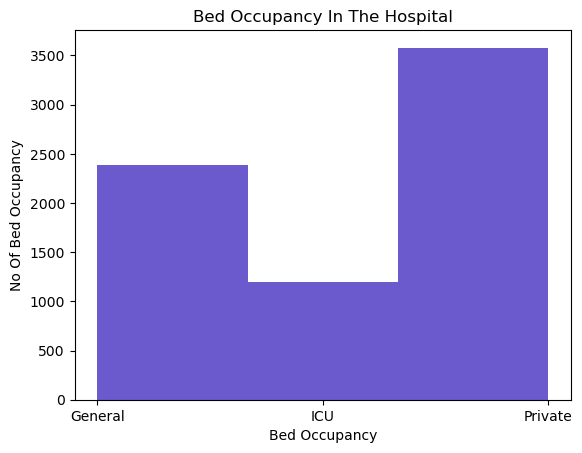

In [47]:
df['Patients_stay_duration']=df['Discharge_Date']- df['Admit_Date']

plt.hist(df['Bed_Occupancy'],bins = 3 , color = ['slateblue'])

plt.xlabel('Bed Occupancy')
plt.ylabel('No Of Bed Occupancy')
plt.title('Bed Occupancy In The Hospital')
plt.show()

In [42]:
df_group_by =df.groupby('Bed_Occupancy')['Billing Amount'].sum().reset_index()
print(df_group_by)

  Bed_Occupancy  Billing Amount
0       General        63164925
1           ICU        40447981
2       Private        86819776


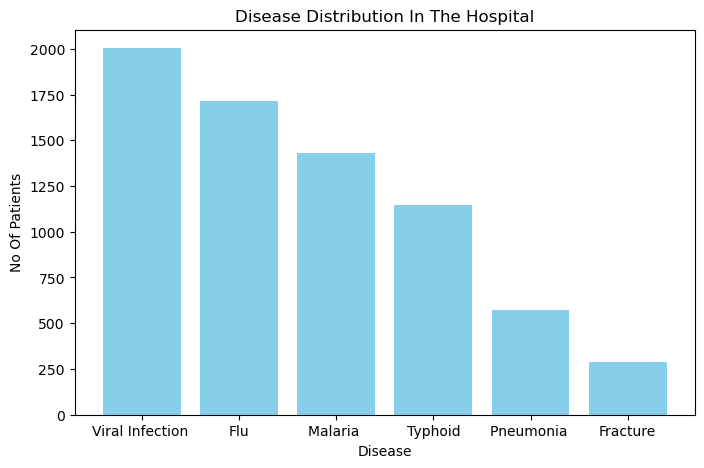

In [54]:
disease_counts = df['Diagnosis'].value_counts()
plt.figure(figsize = (8,5))
plt.bar(disease_counts.index,disease_counts.values,color='skyblue')

plt.xlabel('Disease')
plt.ylabel('No Of Patients')
plt.title('Disease Distribution In The Hospital') 

##plt.xticks(rotation= 45)
plt.show()

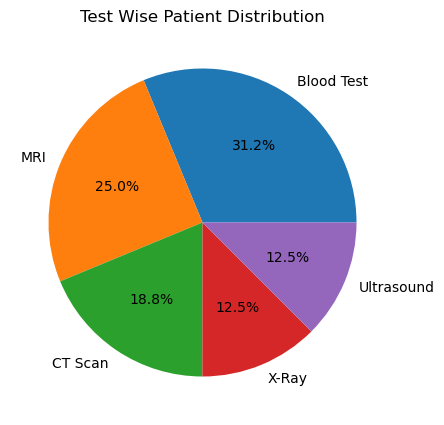

In [60]:
test_counts = df['Test'].value_counts()
plt.figure(figsize = (7,5))
plt.pie(test_counts,labels = test_counts.index,autopct = '%1.1f%%') 
plt.title('Test Wise Patient Distribution')
plt.show()
           

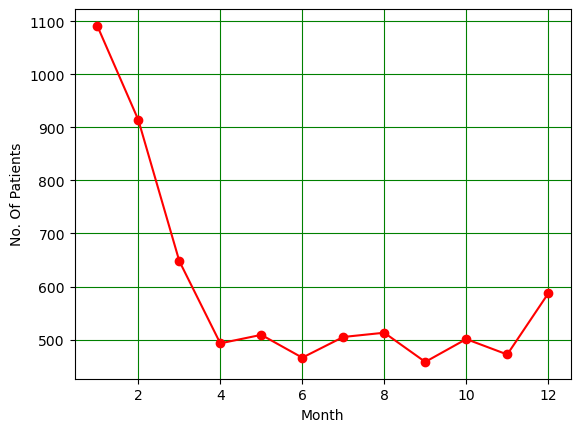

In [62]:
df['month']=month=pd.to_datetime(df['Admit_Date']).dt.month  
df['year']=month=pd.to_datetime(df['Admit_Date']).dt.year

number_of_patients_month=df.groupby('month')['Patient_ID'].count().reset_index()
plt.plot(
    number_of_patients_month['month'],number_of_patients_month['Patient_ID'],marker='o',color='red')
plt.xlabel('Month')
plt.ylabel('No. Of Patients')
plt.grid(color= 'green')
plt.show()

In [63]:
df


,Patient_ID,Admit_Date,Discharge_Date,Diagnosis,Bed_Occupancy,Test,Doctor,Followup Date,Feedback,Billing Amount,Health Insurance Amount,Patients_stay_duration,month,year
0,23571,2022-12-31,2023-01-12,Viral Infection,General,MRI,Jay Sinha,2023-01-20 00:00:00,5.0,13234,11910.6,12 days,12,2022
1,27781,2023-01-04,2023-01-12,Typhoid,ICU,MRI,Jaya Yaadav,2023-01-16 00:00:00,4.0,12241,11016.9,8 days,1,2023
2,24413,2023-01-05,2023-01-12,Malaria,General,CT Scan,Jay Sinha,2023-01-15 00:00:00,5.0,35255,31729.5,7 days,1,2023
3,27360,2023-01-05,2023-01-12,Flu,Private,X-Ray,Jaya Yaadav,2023-01-19 00:00:00,5.0,6582,5923.8,7 days,1,2023
4,26097,2023-01-06,2023-01-12,Viral Infection,General,Blood Test,Jaya Yaadav,2023-02-06 00:00:00,4.9,4567,4110.3,6 days,1,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7152,29885,2024-03-03,2024-03-07,Typhoid,Private,Blood Test,Jay Sinha,2024-03-10 00:00:00,5.0,2342,2107.8,4 days,3,2024
7153,26517,2024-03-04,2024-03-07,Pneumonia,Private,CT Scan,Jaya Yaadav,2024-03-14 00:00:00,5.0,24943,22448.7,3 days,3,2024
7154,28201,2024-03-05,2024-03-07,Flu,General,Blood Test,Jay Sinha,00:00:00,3.5,2343,2108.7,2 days,3,2024
7155,24833,2024-03-06,2024-03-07,Typhoid,Private,X-Ray,Mark Joy,2024-03-15 00:00:00,4.9,3475,3127.5,1 days,3,2024


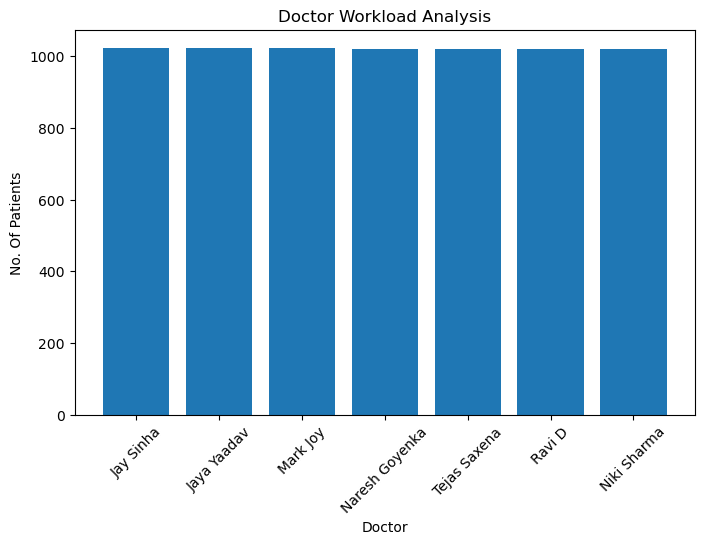

In [91]:
doctor_counts= df['Doctor'].value_counts()   ###find doctor count

plt.figure(figsize=(8,5))
plt.bar(doctor_counts.index,doctor_counts.values)

plt.xlabel('Doctor')
plt.ylabel('No. Of Patients')
plt.title('Doctor Workload Analysis')
plt.xticks(rotation= 45)
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_9568\1971481209.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


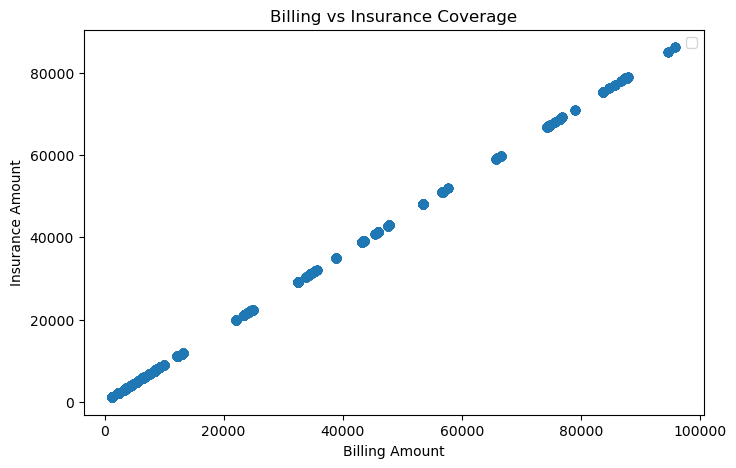

In [92]:
plt.figure(figsize=(8,5))
plt.legend()
plt.scatter(df['Billing Amount'],df['Health Insurance Amount'])
plt.xlabel('Billing Amount')
plt.ylabel('Insurance Amount')
plt.title('Billing vs Insurance Coverage')

plt.show()

In [ ]:
ss